In [ ]:
# !pip install -q timm albumentations torchmetrics

In [ ]:
import os
import cv2
import random
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from PIL import Image
from pathlib import Path
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR

# Albumentations
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Metrics
from torchmetrics import AUROC, Accuracy, F1Score

from sklearn.metrics import (
    classification_report,
    roc_curve,
    auc,
    confusion_matrix
)

from sklearn.model_selection import train_test_split

# Timm
import timm

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


CONFIGURATION

In [ ]:
SEED = 42

IMAGE_SIZE = 224
BATCH_SIZE = 16

NUM_WORKERS = 2

LR = 1e-4
EPOCHS = 30

PATIENCE = 8
WARMUP_EPOCHS = 5

MODEL_NAME = 'mobilenetv3_large_100'

DEVICE = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print("DEVICE:", DEVICE)

DEVICE: cuda


SET SEED

In [ ]:
def set_seed(seed):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

LOAD DATASET

In [ ]:
base_path = "/content/drive/Shareddrives/Machine Learning"

origa_df = pd.read_csv(f"{base_path}/origa_info.csv")
g1020_df = pd.read_csv(f"{base_path}/G1020.csv")
labels_df = pd.read_csv(f"{base_path}/Labels glaukoma.csv")

CLEANING & STANDARISASI

In [ ]:

origa_df = origa_df[['Image', 'Label']]
origa_df['Image'] = origa_df['Image'].apply(os.path.basename)

origa_df.columns = ['image', 'label']


g1020_df = g1020_df[['imageID', 'binaryLabels']]
g1020_df.columns = ['image', 'label']


labels_df = labels_df[['Image Name', 'Label']]

labels_df['Label'] = labels_df['Label'].replace({
    'GON+': 1,
    'GON-': 0
})

labels_df.columns = ['image', 'label']


df = pd.concat([
    origa_df,
    g1020_df,
    labels_df
], ignore_index=True)

PATH GAMBAR

In [ ]:
origa_path = f"{base_path}/ORIGA_Images_Square"
g1020_path = f"{base_path}/G1020_Images_Square"
glaukoma_path = f"{base_path}/Images glaukoma"

def get_image_path(img_name):

    if os.path.exists(os.path.join(origa_path, img_name)):
        return os.path.join(origa_path, img_name)

    elif os.path.exists(os.path.join(g1020_path, img_name)):
        return os.path.join(g1020_path, img_name)

    elif os.path.exists(os.path.join(glaukoma_path, img_name)):
        return os.path.join(glaukoma_path, img_name)

    else:
        return None

df['filepath'] = df['image'].apply(get_image_path)

df = df[df['filepath'].notnull()].reset_index(drop=True)

EDA DISTRIBUSI

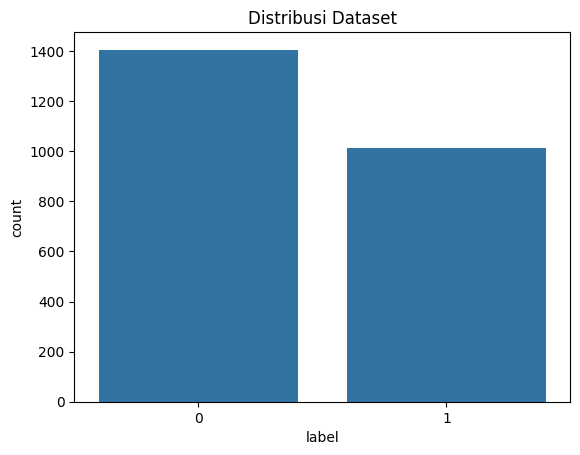

label
0    1405
1    1012
Name: count, dtype: int64


In [ ]:
sns.countplot(x=df['label'])

plt.title("Distribusi Dataset")
plt.show()

print(df['label'].value_counts())

TRAIN/VAL/TEST SPLIT

In [ ]:
df_trainval, df_test = train_test_split(
    df,
    test_size=0.15,
    random_state=SEED,
    stratify=df['label']
)

df_train, df_val = train_test_split(
    df_trainval,
    test_size=0.176,
    random_state=SEED,
    stratify=df_trainval['label']
)

print("Train:", len(df_train))
print("Val:", len(df_val))
print("Test:", len(df_test))

Train: 1692
Val: 362
Test: 363


PREPROCESSING RETINA

In [ ]:
def preprocess_retina(img):

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = cv2.resize(
        img,
        (IMAGE_SIZE, IMAGE_SIZE)
    )


    green = img[:,:,1]


    clahe = cv2.createCLAHE(
        clipLimit=4.0,
        tileGridSize=(8,8)
    )

    green = clahe.apply(green)

    img[:,:,1] = green

    return img

AUGMENTATION

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = A.Compose([

    A.RandomResizedCrop(
        size=(IMAGE_SIZE, IMAGE_SIZE),
        scale=(0.8, 1.0),
        p=1
    ),

    A.HorizontalFlip(p=0.5),

    A.VerticalFlip(p=0.3),

    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.1,
        rotate_limit=30,
        p=0.5
    ),

    A.HueSaturationValue(p=0.3),

    A.CLAHE(p=0.3),

    A.CoarseDropout(
        num_holes_range=(1,4),
        hole_height_range=(16,32),
        hole_width_range=(16,32),
        p=0.3
    ),

    A.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    ),

    ToTensorV2()
])

val_transforms = A.Compose([

    A.Resize(
        IMAGE_SIZE,
        IMAGE_SIZE
    ),

    A.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    ),

    ToTensorV2()
])

DATASET CLASS

In [ ]:
class GlaucomaDataset(Dataset):

    def __init__(self, dataframe, transform=None):

        self.df = dataframe.reset_index(drop=True)

        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        label = torch.tensor(
            row['label'],
            dtype=torch.float32
        )

        img = cv2.imread(row['filepath'])

        img = preprocess_retina(img)

        if self.transform:
            img = self.transform(image=img)['image']

        return img, label

DATALOADER

In [ ]:
train_dataset = GlaucomaDataset(
    df_train,
    transform=train_transforms
)

val_dataset = GlaucomaDataset(
    df_val,
    transform=val_transforms
)

test_dataset = GlaucomaDataset(
    df_test,
    transform=val_transforms
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

MODEL MobileNetV3 + MLP

In [ ]:
class GlaucomaClassifier(nn.Module):

    def __init__(self):

        super().__init__()


        self.backbone = timm.create_model(

            MODEL_NAME,

            pretrained=True,

            num_classes=0,

            global_pool='avg'
        )


        n_features = 1280

        print("Feature Size:", n_features)



        self.classifier = nn.Sequential(

            nn.Linear(n_features, 256),

            nn.ReLU(),

            nn.Dropout(0.4),

            nn.Linear(256, 128),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(128, 1)
        )

    def forward(self, x):

        features = self.backbone(x)

        logits = self.classifier(features)

        return logits.squeeze(1)

    def freeze_backbone(self):

        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_backbone(self):

        for p in self.backbone.parameters():
            p.requires_grad = True

LOAD MODEL

In [ ]:
model = GlaucomaClassifier().to(DEVICE)

model.freeze_backbone()

Feature Size: 1280


FOCAL LOSS

In [ ]:
class FocalLoss(nn.Module):

    def __init__(self,
                 alpha=0.75,
                 gamma=2):

        super().__init__()

        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):

        bce = F.binary_cross_entropy_with_logits(
            logits,
            targets,
            reduction='none'
        )

        pt = torch.exp(-bce)

        alpha = self.alpha * targets + \
                (1 - self.alpha) * (1 - targets)

        loss = alpha * (1 - pt) ** self.gamma * bce

        return loss.mean()

OPTIMIZER

In [ ]:
criterion = FocalLoss()

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad,
           model.parameters()),
    lr=LR
)

scheduler = CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)

TRAINING FUNCTION

In [ ]:
def train_one_epoch(model,
                    loader,
                    criterion,
                    optimizer):

    model.train()

    running_loss = 0.0

    all_preds = []
    all_labels = []

    for images, labels in tqdm(
        loader,
        desc='[TRAIN]',
        leave=False
    ):

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )



        optimizer.zero_grad()


        logits = model(images)



        loss = criterion(
            logits,
            labels
        )



        loss.backward()



        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )



        optimizer.step()



        running_loss += (
            loss.item() * images.size(0)
        )



        probs = torch.sigmoid(
            logits
        ).detach()

        all_preds.append(probs)

        all_labels.append(
            labels.detach().long()
        )



    all_preds = torch.cat(all_preds)

    all_labels = torch.cat(all_labels)



    epoch_loss = (
        running_loss / len(loader.dataset)
    )

    epoch_auc = auc_metric(
        all_preds,
        all_labels
    ).item()

    epoch_acc = acc_metric(
        all_preds,
        all_labels
    ).item()



    auc_metric.reset()

    acc_metric.reset()

    return (
        epoch_loss,
        epoch_auc,
        epoch_acc
    )

METRICS

In [ ]:
auc_metric = AUROC(task='binary').to(DEVICE)

acc_metric = Accuracy(task='binary').to(DEVICE)

f1_metric = F1Score(task='binary').to(DEVICE)

TRAIN FUNCTION

In [ ]:
def train_one_epoch(model,
                    loader,
                    criterion,
                    optimizer):

    model.train()

    running_loss = 0.0

    all_preds = []
    all_labels = []

    for images, labels in tqdm(loader):

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        logits = model(images)

        loss = criterion(logits, labels)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        probs = torch.sigmoid(logits).detach()

        all_preds.append(probs)

        all_labels.append(labels.long())

    all_preds = torch.cat(all_preds)

    all_labels = torch.cat(all_labels)

    epoch_loss = running_loss / len(loader.dataset)

    epoch_auc = auc_metric(
        all_preds,
        all_labels
    ).item()

    epoch_acc = acc_metric(
        all_preds,
        all_labels
    ).item()

    auc_metric.reset()
    acc_metric.reset()

    return epoch_loss, epoch_auc, epoch_acc

VALIDATION FUNCTION

In [ ]:
@torch.no_grad()

def validate(model,
             loader,
             criterion):

    model.eval()

    running_loss = 0.0

    all_preds = []
    all_labels = []

    for images, labels in tqdm(loader):

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        logits = model(images)

        loss = criterion(logits, labels)

        running_loss += loss.item() * images.size(0)

        all_preds.append(
            torch.sigmoid(logits)
        )

        all_labels.append(
            labels.long()
        )

    all_preds = torch.cat(all_preds)

    all_labels = torch.cat(all_labels)

    epoch_loss = running_loss / len(loader.dataset)

    epoch_auc = auc_metric(
        all_preds,
        all_labels
    ).item()

    epoch_acc = acc_metric(
        all_preds,
        all_labels
    ).item()

    epoch_f1 = f1_metric(
        all_preds,
        all_labels
    ).item()

    auc_metric.reset()
    acc_metric.reset()
    f1_metric.reset()

    return (
        epoch_loss,
        epoch_auc,
        epoch_acc,
        epoch_f1
    )

TRAINING LOOP

In [ ]:
history = {

    'train_loss': [],
    'val_loss': [],

    'train_auc': [],
    'val_auc': [],

    'train_acc': [],
    'val_acc': [],

    'val_f1': [],
    'lr': []
}

best_auc = 0.0

patience_ctr = 0

CHECKPOINT = '/content/best_model.pth'

RUN TRAINING

In [ ]:
for epoch in range(1, EPOCHS + 1):



    if epoch == WARMUP_EPOCHS + 1:

        print("\nUNFREEZE BACKBONE")

        model.unfreeze_backbone()

        optimizer = optim.AdamW(
            model.parameters(),
            lr=LR * 0.1
        )

        scheduler = CosineAnnealingLR(
            optimizer,
            T_max=EPOCHS
        )

    current_lr = optimizer.param_groups[0]['lr']


    tr_loss, tr_auc, tr_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )


    vl_loss, vl_auc, vl_acc, vl_f1 = validate(
        model,
        val_loader,
        criterion
    )

    scheduler.step()


    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)

    history['train_auc'].append(tr_auc)
    history['val_auc'].append(vl_auc)

    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    history['val_f1'].append(vl_f1)

    history['lr'].append(current_lr)


    print(

        f'Epoch {epoch:02d}/{EPOCHS} | '

        f'LR={current_lr:.1e} | '

        f'Train Loss={tr_loss:.4f} '
        f'AUC={tr_auc:.4f} | '

        f'Val Loss={vl_loss:.4f} '
        f'AUC={vl_auc:.4f} '
        f'F1={vl_f1:.4f}'
    )


    if vl_auc > best_auc:

        best_auc = vl_auc

        patience_ctr = 0

        torch.save({

            'model_state_dict':
            model.state_dict(),

            'best_auc':
            best_auc

        }, CHECKPOINT)

        print('BEST MODEL SAVED')

    else:

        patience_ctr += 1

        print(f'No improvement ({patience_ctr}/{PATIENCE})')


    if patience_ctr >= PATIENCE:

        print('EARLY STOPPING')

        break

  0%|          | 0/106 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

Epoch 01/30 | LR=1.0e-04 | Train Loss=0.0694 AUC=0.6423 | Val Loss=0.0639 AUC=0.7622 F1=0.5984
BEST MODEL SAVED


  0%|          | 0/106 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

...

  0%|          | 0/23 [00:00<?, ?it/s]

Epoch 29/30 | LR=1.3e-06 | Train Loss=0.0502 AUC=0.8396 | Val Loss=0.0507 AUC=0.8278 F1=0.7114
No improvement (4/8)


  0%|          | 0/106 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

Epoch 30/30 | LR=9.5e-07 | Train Loss=0.0503 AUC=0.8358 | Val Loss=0.0512 AUC=0.8231 F1=0.7025
No improvement (5/8)


Visualisasi Hasil Epoch

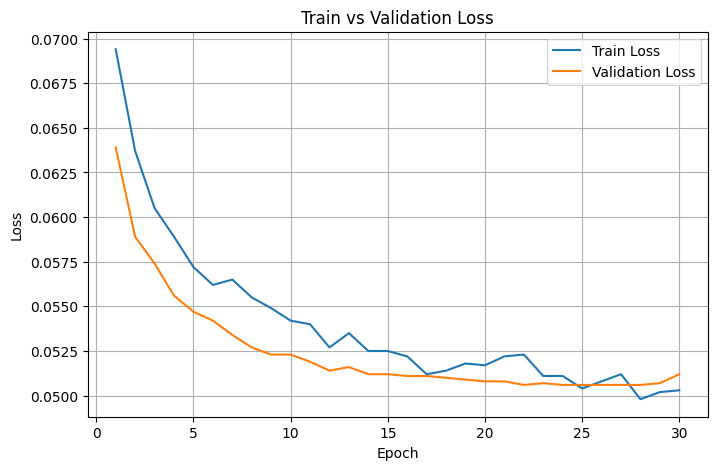

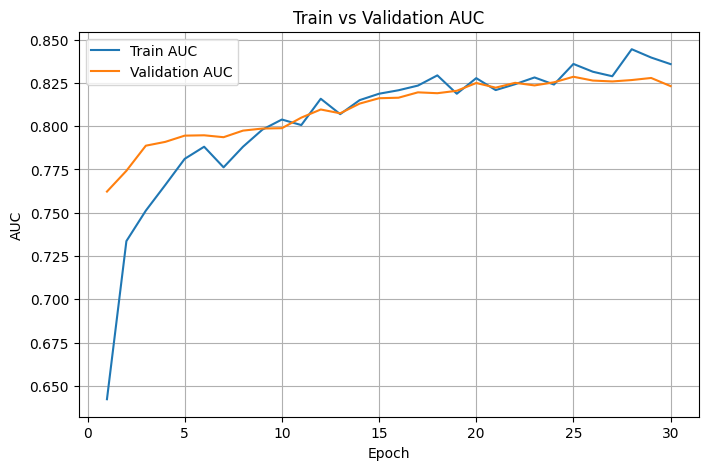

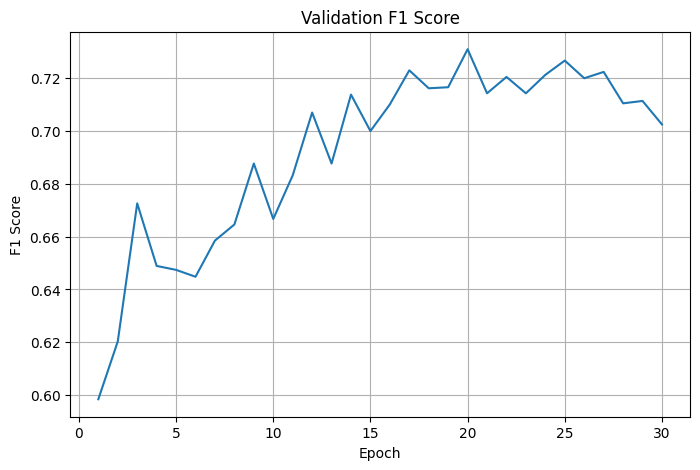

In [ ]:
import matplotlib.pyplot as plt

epochs = list(range(1, 31))

train_loss = [
0.0694,0.0637,0.0605,0.0589,0.0572,
0.0562,0.0565,0.0555,0.0549,0.0542,
0.0540,0.0527,0.0535,0.0525,0.0525,
0.0522,0.0512,0.0514,0.0518,0.0517,
0.0522,0.0523,0.0511,0.0511,0.0504,
0.0508,0.0512,0.0498,0.0502,0.0503
]

val_loss = [
0.0639,0.0589,0.0574,0.0556,0.0547,
0.0542,0.0534,0.0527,0.0523,0.0523,
0.0519,0.0514,0.0516,0.0512,0.0512,
0.0511,0.0511,0.0510,0.0509,0.0508,
0.0508,0.0506,0.0507,0.0506,0.0506,
0.0506,0.0506,0.0506,0.0507,0.0512
]

train_auc = [
0.6423,0.7336,0.7512,0.7660,0.7811,
0.7881,0.7762,0.7881,0.7980,0.8038,
0.8006,0.8158,0.8069,0.8150,0.8187,
0.8207,0.8234,0.8293,0.8187,0.8277,
0.8208,0.8242,0.8281,0.8240,0.8359,
0.8314,0.8288,0.8444,0.8396,0.8358
]

val_auc = [
0.7622,0.7742,0.7887,0.7909,0.7945,
0.7947,0.7936,0.7974,0.7986,0.7988,
0.8049,0.8096,0.8074,0.8130,0.8161,
0.8164,0.8195,0.8190,0.8204,0.8249,
0.8222,0.8250,0.8235,0.8253,0.8285,
0.8263,0.8258,0.8266,0.8278,0.8231
]

val_f1 = [
0.5984,0.6203,0.6726,0.6489,0.6474,
0.6448,0.6585,0.6646,0.6877,0.6667,
0.6832,0.7070,0.6877,0.7138,0.7000,
0.7101,0.7230,0.7162,0.7166,0.7310,
0.7143,0.7205,0.7143,0.7213,0.7267,
0.7200,0.7224,0.7105,0.7114,0.7025
]

# =========================
# LOSS
# =========================
plt.figure(figsize=(8,5))
plt.plot(epochs, train_loss, label='Train Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# =========================
# AUC
# =========================
plt.figure(figsize=(8,5))
plt.plot(epochs, train_auc, label='Train AUC')
plt.plot(epochs, val_auc, label='Validation AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.title('Train vs Validation AUC')
plt.legend()
plt.grid(True)
plt.show()

# =========================
# F1 SCORE
# =========================
plt.figure(figsize=(8,5))
plt.plot(epochs, val_f1)
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.title('Validation F1 Score')
plt.grid(True)
plt.show()

Cek dtype

In [ ]:
dtype_origa = pd.read_csv("/content/drive/Shareddrives/Machine Learning/origa_info.csv")
dtype_g1020 = pd.read_csv("/content/drive/Shareddrives/Machine Learning/G1020.csv")
dtype_glaukoma = pd.read_csv("/content/drive/Shareddrives/Machine Learning/Labels glaukoma.csv")

In [ ]:
dtype_origa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 650 entries, 0 to 649
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Image     650 non-null    object 
 1   Source    650 non-null    object 
 2   Cropped   650 non-null    bool   
 3   CDR       650 non-null    float64
 4   Ecc-Cup   650 non-null    float64
 5   Ecc-Disc  650 non-null    float64
 6   Label     650 non-null    int64  
dtypes: bool(1), float64(3), int64(1), object(2)
memory usage: 31.2+ KB


In [ ]:
dtype_g1020.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   imageID       1020 non-null   object
 1   binaryLabels  1020 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 16.1+ KB


In [ ]:
dtype_glaukoma.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 747 entries, 0 to 746
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Image Name     747 non-null    object 
 1   Patient        747 non-null    int64  
 2   Label          747 non-null    object 
 3   Quality Score  747 non-null    float64
 4   Unnamed: 4     0 non-null      float64
dtypes: float64(2), int64(1), object(2)
memory usage: 29.3+ KB
